# Magnetic Sensitivity and Transition Strengths — V2

This notebook is the plotting companion to `Hamiltonian_Solver_V2.py`.

It reproduces the same style of \(^{137}\mathrm{Ba}^+\)
\(6S_{1/2}(F=2)\leftrightarrow 5D_{5/2}\) transition maps as the original
`MagSen_and_transStrength.ipynb`, but uses the **adiabatic \((F,m_F)\) labels**
from the V2 Hamiltonian solver.

### Important conventions

- Rows are the adiabatic \(5D_{5/2}\) states, grouped by \(F=1,2,3,4\), with \(m_F\) descending within each \(F\).
- Columns are \(6S_{1/2},F=2\), ordered \(m_F=-2,-1,0,+1,+2\).
- The optical transition-strength map is an **E2 line strength** \(S=|M|^2\).
- The quadrupole geometric factors are the same ones retained in `Hamiltonian_Solver_V2`.
- Magnetic sensitivity is \(d\nu/dB\) in MHz/G. The heatmap color uses \(|d\nu/dB|\), while the cell annotation keeps the sign.
- Cells with \(|\Delta m_F|>2\) are masked, matching the E2 selection rule.

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches

import Hamiltonian_Solver_V2 as ba
from matplotlib import rcParams
# Portable Computer-Modern-like math styling without requiring a system LaTeX install.
# plt.rcParams.update({
#     "font.family": "serif",
#     "mathtext.fontset": "cm",
#     "axes.titlesize": 17,
#     "axes.labelsize": 14,
#     "xtick.labelsize": 12,
#     "ytick.labelsize": 11,
#     "figure.dpi": 120,
# })

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True

# Increase font sizes
rcParams['axes.titlesize'] = 17      # Title of the plot
rcParams['axes.labelsize'] = 14      # Axis labels
rcParams['xtick.labelsize'] = 12     # X tick labels
rcParams['ytick.labelsize'] = 11     # Y tick labels
rcParams['legend.fontsize'] = 18     # Legend text
rcParams['figure.titlesize'] = 17    # Figure-wide title (if used)

# Confirm that the solver itself passes its internal validation suite.
solver_ok, solver_tests = ba.run_self_tests(verbose=False)
assert solver_ok, "Hamiltonian_Solver_V2 self-tests did not pass."
print(f"Hamiltonian_Solver_V2 loaded successfully: {len(solver_tests)} tests available; all passed.")

Hamiltonian_Solver_V2 loaded successfully: 95 tests available; all passed.


## User settings

In [12]:
# These are the only values most users need to change.

B_GAUSS = 4.2079
F0_MHZ = 546.506966

# E2 beam geometry, using the same convention/geometric factors as Hamiltonian Solver V2.
THETA_K_DEG = 45.0
THETA_P_DEG = 58.0

# If True, transition strengths are divided by the strongest allowed transition.
NORMALIZE_STRENGTH = True

# Finite-difference step for d(nu)/dB.
DELTA_B_GAUSS = 1e-4

## Label-safe data preparation

In [13]:
def ket_label(F, mF):
    """Compact adiabatic-state label used on the heatmap axes."""
    return rf"$|\widetilde{{F}}={F},\,m_{{\widetilde{{F}}}}={mF:+d}\rangle$"


def transition_map_labels():
    """
    Return the exact row/column labels used by the V2 frequency table.

    Rows: D5/2 adiabatic labels.
    Cols: S1/2, F=2 adiabatic labels.
    """
    return list(ba.D52_FREQ_ROW_LABELS), list(ba.S12_FREQ_COL_LABELS)


def e2_transition_strength_grid(
    B_gauss,
    theta_k=45.0,
    theta_p=58.0,
    normalize=True,
):
    """
    Return a 24 x 5 E2 transition-strength grid in exactly the same
    row/column ordering as generate_frequencies_at() and
    generate_magnetic_field_sensitivity().

    Values are |M|^2. Forbidden |Delta mF| > 2 entries are NaN.
    """
    full = ba.TransitionStrength(
        B_gauss,
        theta_k=theta_k,
        theta_p=theta_p,
        normalize=False,
    )

    row_labels, col_labels = transition_map_labels()
    grid = np.full((len(row_labels), len(col_labels)), np.nan, dtype=float)

    for r, (Fd, md) in enumerate(row_labels):
        i_d = ba.state_index("D52", Fd, md)

        for c, (Fs, ms) in enumerate(col_labels):
            if abs(md - ms) > 2:
                continue

            i_s = ba.state_index("S12", Fs, ms)
            grid[r, c] = full[i_d, i_s]

    if normalize:
        maximum = np.nanmax(grid)
        if np.isfinite(maximum) and maximum > 0:
            grid = grid / maximum

    return grid


def magnetic_sensitivity_grid(B_gauss, delta_B=1e-4):
    """
    Return d(nu)/dB [MHz/G] in the same 24 x 5 transition ordering.
    Forbidden E2 transitions are masked as NaN.
    """
    sensitivity = ba.generate_magnetic_field_sensitivity(
        B_gauss,
        delta_B=delta_B,
    ).astype(float)

    row_labels, col_labels = transition_map_labels()

    for r, (_, md) in enumerate(row_labels):
        for c, (_, ms) in enumerate(col_labels):
            if abs(md - ms) > 2:
                sensitivity[r, c] = np.nan

    return sensitivity


def transition_frequency_grid(B_gauss, f0_mhz=546.1206708):
    """Calibrated 1762-nm transition-frequency table [MHz]."""
    return ba.generate_frequencies_at(B_gauss, f0=f0_mhz)

## Heatmap plotting functions

In [14]:
def _heatmap_axes_labels(ax):
    row_labels, col_labels = transition_map_labels()

    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))

    ax.set_xticklabels(
        [ket_label(F, mF) for F, mF in col_labels],
        rotation=18,
        ha="center",
    )
    ax.set_yticklabels(
        [ket_label(F, mF) for F, mF in row_labels],
    )

    ax.set_xlabel(r"$6S_{1/2}$ initial state")
    ax.set_ylabel(r"$5D_{5/2}$ final state")


def _add_transition_boxes(ax, transitions, edgecolor="red", linewidth=2.0):
    """
    Draw boxes around chosen transitions.

    Each transition is (mF_S12, F_D52, mF_D52), matching the tuple
    convention used in the original plotting notebook.
    """
    if transitions is None:
        return

    row_labels, col_labels = transition_map_labels()
    row_map = {label: i for i, label in enumerate(row_labels)}
    col_map = {mF: i for i, (_, mF) in enumerate(col_labels)}

    for mF_s, F_d, mF_d in transitions:
        key = (int(F_d), int(mF_d))
        if key not in row_map or int(mF_s) not in col_map:
            continue

        r = row_map[key]
        c = col_map[int(mF_s)]
        ax.add_patch(
            patches.Rectangle(
                (c - 0.5, r - 0.5),
                1,
                1,
                fill=False,
                edgecolor=edgecolor,
                linewidth=linewidth,
            )
        )


def plot_magnetic_sensitivity(
    B_gauss=B_GAUSS,
    f0_mhz=F0_MHZ,
    delta_B=DELTA_B_GAUSS,
    annotate=True,
    show_colorbar=False,
    highlights=None,
    save=None,
):
    """
    Plot |d(nu)/dB| as the heatmap color and annotate signed d(nu)/dB.

    Returns
    -------
    fig, ax, sensitivity, frequencies
    """
    sensitivity = magnetic_sensitivity_grid(B_gauss, delta_B=delta_B)
    frequencies = transition_frequency_grid(B_gauss, f0_mhz=f0_mhz)

    color_values = np.abs(sensitivity)
    masked = np.ma.masked_invalid(color_values)

    fig, ax = plt.subplots(figsize=(10.5, 12.5))
    im = ax.imshow(masked, aspect="auto", cmap="viridis_r")
    _heatmap_axes_labels(ax)

    if annotate:
        vmax = np.nanmax(color_values)
        for r in range(sensitivity.shape[0]):
            for c in range(sensitivity.shape[1]):
                kappa = sensitivity[r, c]
                freq = frequencies[r, c]

                if not np.isfinite(kappa) or not np.isfinite(freq):
                    continue

                text_color = "white" if abs(kappa) > 0.58 * vmax else "black"

                ax.text(
                    c,
                    r,
                    rf"$f_n$: {freq:.3f}" + "\n" + rf"$\kappa$: {kappa:+.5f}",
                    ha="center",
                    va="center",
                    fontsize=10.5,
                    color=text_color,
                )

    _add_transition_boxes(ax, highlights)

    ax.set_title(
        rf"Magnetic-field sensitivity at $B={B_gauss:.4f}$ G "
        r"$(\mathrm{MHz/G})$"
    )

    if show_colorbar:
        cbar = fig.colorbar(im, ax=ax, pad=0.02)
        cbar.set_label(r"$|d\nu/dB|$ (MHz/G)")

    fig.tight_layout()

    if save is not None:
        fig.savefig(save, bbox_inches="tight")

    return fig, ax, sensitivity, frequencies


def plot_transition_strengths(
    B_gauss=B_GAUSS,
    f0_mhz=F0_MHZ,
    theta_k=THETA_K_DEG,
    theta_p=THETA_P_DEG,
    normalize=NORMALIZE_STRENGTH,
    annotate=True,
    show_colorbar=False,
    highlights=None,
    save=None,
):
    """
    Plot S = |M|^2 for S1/2(F=2) -> D5/2 E2 transitions.

    The quadrupole geometric factors are taken directly from
    Hamiltonian_Solver_V2.
    """
    strengths = e2_transition_strength_grid(
        B_gauss,
        theta_k=theta_k,
        theta_p=theta_p,
        normalize=normalize,
    )
    frequencies = transition_frequency_grid(B_gauss, f0_mhz=f0_mhz)

    masked = np.ma.masked_invalid(strengths)

    fig, ax = plt.subplots(figsize=(10.5, 12.5))
    im = ax.imshow(masked, aspect="auto", cmap="viridis")
    _heatmap_axes_labels(ax)

    if annotate:
        vmax = np.nanmax(strengths)

        for r in range(strengths.shape[0]):
            for c in range(strengths.shape[1]):
                strength = strengths[r, c]
                freq = frequencies[r, c]

                if not np.isfinite(strength) or not np.isfinite(freq):
                    continue

                text_color = "white" if strength < 0.45 * vmax else "black"

                ax.text(
                    c,
                    r,
                    rf"$f_n$: {freq:.3f}" + "\n" + rf"$S$: {strength:.5f}",
                    ha="center",
                    va="center",
                    fontsize=10.5,
                    color=text_color,
                )

    _add_transition_boxes(ax, highlights)

    scale_text = "relative, max = 1" if normalize else r"$|M|^2$"
    ax.set_title(
        rf"E2 transition strength at $B={B_gauss:.4f}$ G "
        rf"($\theta_k={theta_k:g}^\circ$, $\theta_p={theta_p:g}^\circ$; {scale_text})"
    )

    if show_colorbar:
        cbar = fig.colorbar(im, ax=ax, pad=0.02)
        cbar.set_label("Relative strength" if normalize else r"$|M|^2$")

    fig.tight_layout()

    if save is not None:
        fig.savefig(save, bbox_inches="tight")

    return fig, ax, strengths, frequencies


def plot_transition_summary(
    B_gauss=B_GAUSS,
    f0_mhz=F0_MHZ,
    theta_k=THETA_K_DEG,
    theta_p=THETA_P_DEG,
    normalize_strength=NORMALIZE_STRENGTH,
    delta_B=DELTA_B_GAUSS,
    highlights=None,
    save_prefix=None,
):
    """
    Convenience function: create both V2 heatmaps with one call.

    Returns a dictionary containing both figures and all plotted arrays.
    """
    mag_save = None
    str_save = None
    if save_prefix is not None:
        p = Path(save_prefix)
        mag_save = p.with_name(p.name + "_magnetic_sensitivity.pdf")
        str_save = p.with_name(p.name + "_transition_strength.pdf")

    fig_mag, ax_mag, mag, freqs = plot_magnetic_sensitivity(
        B_gauss=B_gauss,
        f0_mhz=f0_mhz,
        delta_B=delta_B,
        highlights=highlights,
        save=mag_save,
    )

    fig_str, ax_str, strengths, _ = plot_transition_strengths(
        B_gauss=B_gauss,
        f0_mhz=f0_mhz,
        theta_k=theta_k,
        theta_p=theta_p,
        normalize=normalize_strength,
        highlights=highlights,
        save=str_save,
    )

    return {
        "magnetic_figure": fig_mag,
        "magnetic_axes": ax_mag,
        "strength_figure": fig_str,
        "strength_axes": ax_str,
        "magnetic_sensitivity_MHz_per_G": mag,
        "transition_strength": strengths,
        "frequencies_MHz": freqs,
    }

## Quick use

For the common case, one call makes both plots:

```python
results = plot_transition_summary(B_gauss=4.209)
```

To reproduce the quadrupole geometry with different beam angles:

```python
results = plot_transition_summary(
    B_gauss=4.209,
    theta_k=45,
    theta_p=58,
)
```

To highlight selected cells using the old notebook's tuple convention
`(mF_S12, F_D52, mF_D52)`:

```python
highlight = [
    (0, 2, 0),
    (-1, 4, -3),
]
results = plot_transition_summary(
    B_gauss=4.209,
    highlights=highlight,
)
```

## Example: magnetic-field sensitivity

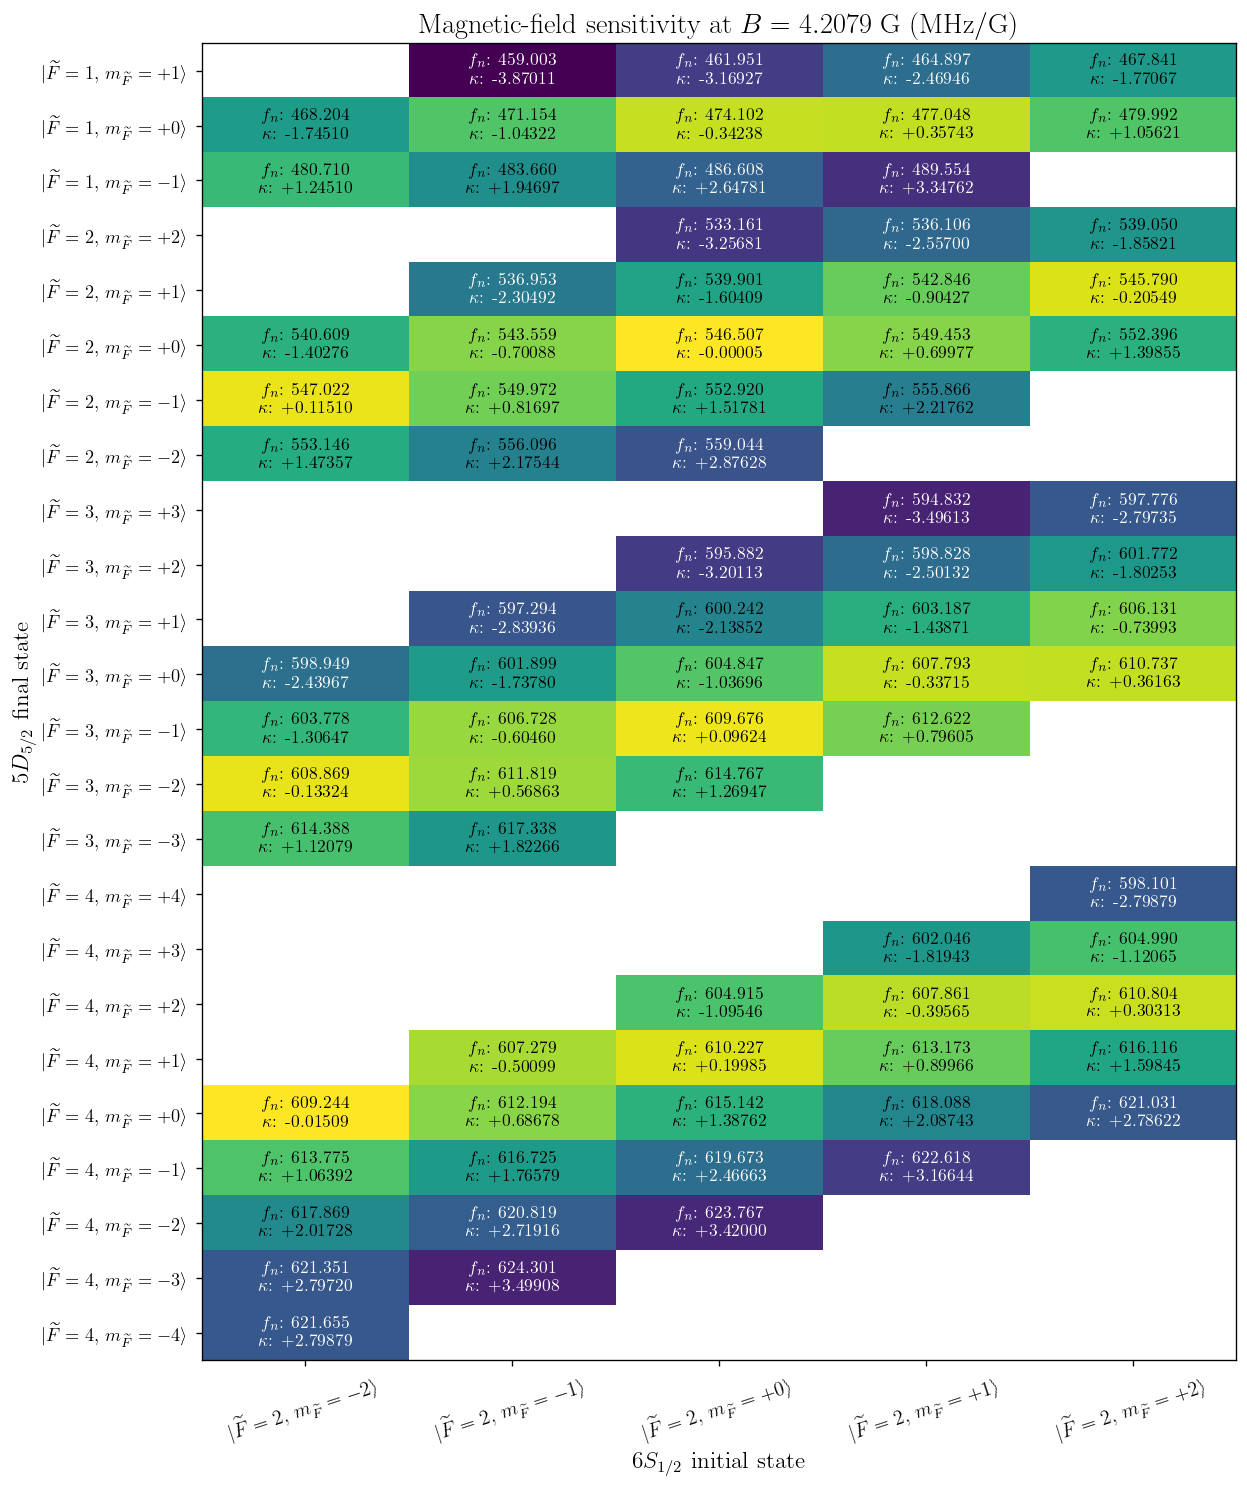

In [15]:
fig_mag, ax_mag, mag_sensitivity, frequencies = plot_magnetic_sensitivity(
    B_gauss=B_GAUSS,
    f0_mhz=F0_MHZ,
    delta_B=DELTA_B_GAUSS,
)
plt.show()

## Example: E2 transition strengths

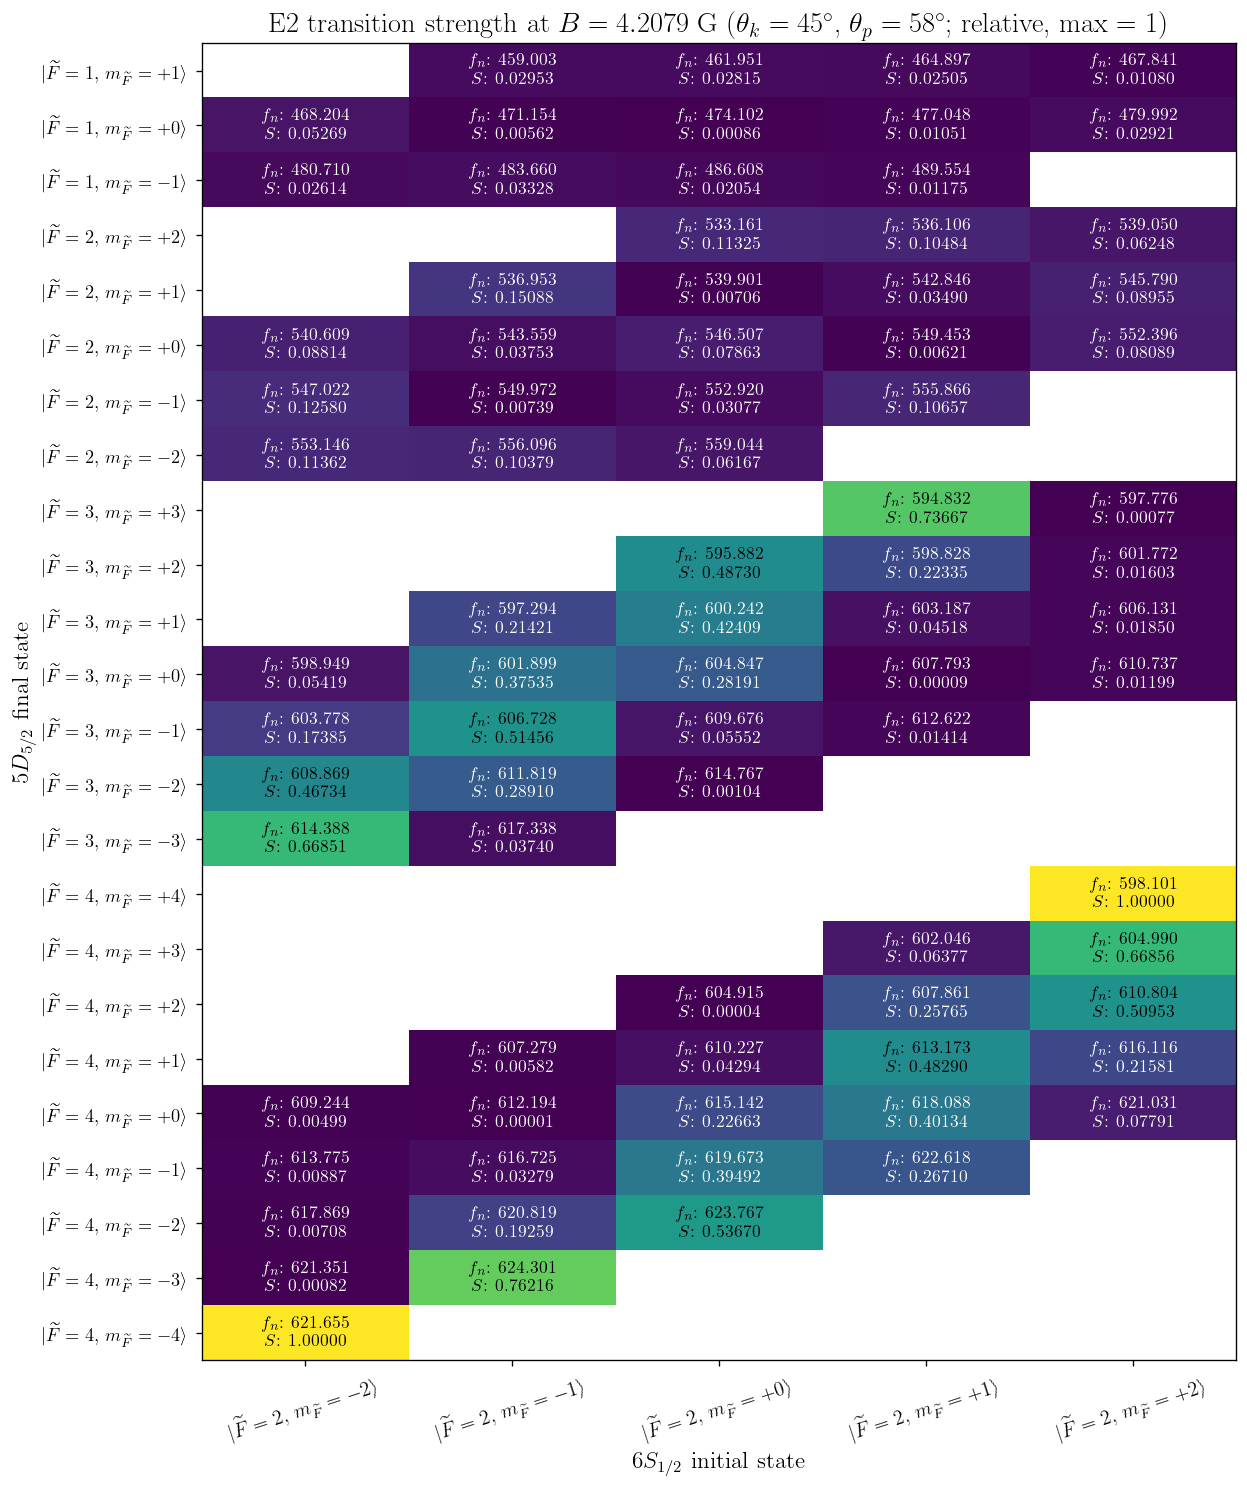

In [17]:
fig_strength, ax_strength, strengths, frequencies = plot_transition_strengths(
    B_gauss=B_GAUSS,
    f0_mhz=F0_MHZ,
    theta_k=THETA_K_DEG,
    theta_p=THETA_P_DEG,
    normalize=NORMALIZE_STRENGTH,
)
plt.show()

## Data tables

In [18]:
row_labels, col_labels = transition_map_labels()

strength_table = pd.DataFrame(
    strengths,
    index=[f"D52 F={F}, mF={mF:+d}" for F, mF in row_labels],
    columns=[f"S12 F={F}, mF={mF:+d}" for F, mF in col_labels],
)

magnetic_table = pd.DataFrame(
    mag_sensitivity,
    index=strength_table.index,
    columns=strength_table.columns,
)

display(strength_table)
display(magnetic_table)

,"S12 F=2, mF=-2","S12 F=2, mF=-1","S12 F=2, mF=+0","S12 F=2, mF=+1","S12 F=2, mF=+2"
"D52 F=1, mF=+1",NaN,0.029532,0.028154,0.025048,0.010802
"D52 F=1, mF=+0",0.052686,0.005617,0.000858,0.010508,0.029210
"D52 F=1, mF=-1",0.026137,0.033283,0.020535,0.011750,NaN
"D52 F=2, mF=+2",NaN,NaN,0.113249,0.104844,0.062476
"D52 F=2, mF=+1",NaN,0.150876,0.007057,0.034903,0.089554
"D52 F=2, mF=+0",0.088137,0.037535,0.078626,0.006206,0.080889
"D52 F=2, mF=-1",0.125801,0.007391,0.030770,0.106569,NaN
"D52 F=2, mF=-2",0.113616,0.103794,0.061670,NaN,NaN
"D52 F=3, mF=+3",NaN,NaN,NaN,0.736671,0.000765
"D52 F=3, mF=+2",NaN,NaN,0.487302,0.223347,0.016028


,"S12 F=2, mF=-2","S12 F=2, mF=-1","S12 F=2, mF=+0","S12 F=2, mF=+1","S12 F=2, mF=+2"
"D52 F=1, mF=+1",NaN,-3.870111,-3.169272,-2.469461,-1.770675
"D52 F=1, mF=+0",-1.745095,-1.043224,-0.342384,0.357427,1.056213
"D52 F=1, mF=-1",1.245096,1.946967,2.647806,3.347617,NaN
"D52 F=2, mF=+2",NaN,NaN,-3.256809,-2.556998,-1.858212
"D52 F=2, mF=+1",NaN,-2.304925,-1.604085,-0.904274,-0.205488
"D52 F=2, mF=+0",-1.402756,-0.700885,-0.000045,0.699766,1.398552
"D52 F=2, mF=-1",0.115101,0.816972,1.517812,2.217623,NaN
"D52 F=2, mF=-2",1.473565,2.175436,2.876276,NaN,NaN
"D52 F=3, mF=+3",NaN,NaN,NaN,-3.496132,-2.797346
"D52 F=3, mF=+2",NaN,NaN,-3.201127,-2.501316,-1.802530


## Plotting consistency checks

In [19]:
# These checks catch the exact ordering problem that existed in the old plotting notebook.

assert strengths.shape == (24, 5)
assert mag_sensitivity.shape == (24, 5)
assert frequencies.shape == (24, 5)

rows, cols = transition_map_labels()

# Every forbidden E2 transition must be masked in all plotted arrays.
for r, (_, md) in enumerate(rows):
    for c, (_, ms) in enumerate(cols):
        if abs(md - ms) > 2:
            assert np.isnan(strengths[r, c])
            assert np.isnan(mag_sensitivity[r, c])
            assert np.isnan(frequencies[r, c])

# Check a representative allowed cell against the direct V2 matrix.
Fd, md = rows[5]       # D52(F=2,mF=0)
Fs, ms = cols[2]       # S12(F=2,mF=0)
raw = ba.TransitionStrength(
    B_GAUSS,
    theta_k=THETA_K_DEG,
    theta_p=THETA_P_DEG,
    normalize=False,
)
direct = raw[
    ba.state_index("D52", Fd, md),
    ba.state_index("S12", Fs, ms),
]

if NORMALIZE_STRENGTH:
    direct /= np.nanmax(
        e2_transition_strength_grid(
            B_GAUSS,
            THETA_K_DEG,
            THETA_P_DEG,
            normalize=False,
        )
    )

assert np.isclose(strengths[5, 2], direct, rtol=1e-12, atol=1e-14)

print("Plotting-order and selection-rule checks passed.")

Plotting-order and selection-rule checks passed.
